# Medicare Skilled Nursing Facility (SNF) Payment Analysis

**Author:** Salia Berthe  
**Date:** February 2026  
**Objective:** Analyze Medicare SNF standardized payment data (2019–2023) to produce summary statistics, identify geographic variation, and visualize longitudinal trends.

**Data Source:** [CMS Medicare Post-Acute Care & Hospice — SNF Utilization](https://data.cms.gov/provider-summary-by-type-of-service/medicare-post-acute-care-hospice/medicare-post-acute-care-utilization-skilled-nursing-facility)  
**Data Dictionary:** [SNF Data Dictionary](https://data.cms.gov/resources/medicare-pac-utilization-snf-data-dictionary)  
**Access Date:** February 2026

---

### Structure
- **Part 1:** Quantitative analysis of 2023 data (summary stats, state comparison, dual-eligible comparison)
- **Part 2:** Longitudinal trend for balanced provider panel (2019–2023)

In [ ]:
# --- Section 0: Setup ---
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Config
DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# DuckDB in-memory connection
con = duckdb.connect()
print(f'DuckDB {duckdb.__version__} ready')

DuckDB 0.8.1 ready


### Why DuckDB?

DuckDB provides a PostgreSQL-compatible SQL dialect with full support for:
- `PERCENTILE_CONT` (ordered-set aggregate for percentiles)
- `FILTER` clauses on aggregates
- `FULL OUTER JOIN`
- Window functions
- Direct CSV ingestion via `read_csv_auto()`

This allows writing the same SQL used in PostgreSQL, while running entirely in-process (no server needed).

---
## Section 1: Data Loading & Quality Checks

In [ ]:
# Load 2023 data into DuckDB
con.execute("""
    CREATE OR REPLACE TABLE mcpac_snf_2023 AS
    SELECT * FROM read_csv_auto('data/mcpac-snf_2023.csv', header=true, ignore_errors=true)
""")

# Inspect schema
con.execute("DESCRIBE mcpac_snf_2023").fetchdf()

,column_name,column_type,null,key,default,extra
0,YEAR,BIGINT,YES,NaN,NaN,NaN
1,YEAR_TYPE,VARCHAR,YES,NaN,NaN,NaN
2,SMRY_CTGRY,VARCHAR,YES,NaN,NaN,NaN
3,SRVC_CTGRY,VARCHAR,YES,NaN,NaN,NaN
4,PRVDR_ID,VARCHAR,YES,NaN,NaN,NaN
...,...,...,...,...,...,...
64,PRMRY_DX_GUSYSTM_PCT,VARCHAR,YES,NaN,NaN,NaN
65,PRMRY_DX_PRGPERICONG_PCT,VARCHAR,YES,NaN,NaN,NaN
66,PRMRY_DX_SXILLDEF_PCT,VARCHAR,YES,NaN,NaN,NaN
67,PRMRY_DX_INJPOIS_PCT,VARCHAR,YES,NaN,NaN,NaN


In [3]:
# QC: Row counts by SMRY_CTGRY
con.execute("""
    SELECT SMRY_CTGRY, COUNT(*) AS row_count
    FROM mcpac_snf_2023
    GROUP BY SMRY_CTGRY
    ORDER BY row_count DESC
""").fetchdf()

,SMRY_CTGRY,row_count
0,PROVIDER,14161
1,STATE,52
2,NATION,1


In [4]:
# QC: Null checks on key columns for PROVIDER rows
con.execute("""
    SELECT
        COUNT(*) AS total_providers,
        COUNT(*) - COUNT(PRVDR_ID)           AS null_prvdr_id,
        COUNT(*) - COUNT(STATE)               AS null_state,
        COUNT(*) - COUNT(TOT_MDCR_STDZD_PYMT_AMT) AS null_pymt,
        COUNT(*) - COUNT(BENE_DUAL_PCT)       AS null_dual_pct
    FROM mcpac_snf_2023
    WHERE SMRY_CTGRY = 'PROVIDER'
""").fetchdf()

,total_providers,null_prvdr_id,null_state,null_pymt,null_dual_pct
0,14161,0,0,0,0


In [5]:
# QC: Duplicate PRVDR_ID check among PROVIDER rows
con.execute("""
    SELECT PRVDR_ID, COUNT(*) AS cnt
    FROM mcpac_snf_2023
    WHERE SMRY_CTGRY = 'PROVIDER'
    GROUP BY PRVDR_ID
    HAVING COUNT(*) > 1
    ORDER BY cnt DESC
    LIMIT 10
""").fetchdf()

,PRVDR_ID,cnt


### QC Summary

- **Row counts:** 14,161 PROVIDER + 52 STATE + 1 NATIONAL = 14,214 total rows
- **Nulls:** Zero nulls across all key columns (`PRVDR_ID`, `STATE`, `TOT_MDCR_STDZD_PYMT_AMT`, `BENE_DUAL_PCT`) for PROVIDER rows
- **Duplicates:** No duplicate `PRVDR_ID` values among PROVIDER rows
- **Suppressed values:** No suppressed/missing payment values in 2023 data — all 14,161 providers have valid `TOT_MDCR_STDZD_PYMT_AMT`

---
## Section 2: Part 1 — Quantitative Analysis (2023 Data)

Using only `SMRY_CTGRY = 'PROVIDER'` rows. All means are unweighted (each provider counts equally).

In [6]:
# Summary statistics for TOT_MDCR_STDZD_PYMT_AMT
summary_sql = """
    SELECT
        COUNT(TOT_MDCR_STDZD_PYMT_AMT) AS provider_count,
        ROUND(AVG(TOT_MDCR_STDZD_PYMT_AMT), 2) AS mean_pymt,
        ROUND(STDDEV(TOT_MDCR_STDZD_PYMT_AMT), 2) AS std_pymt,
        ROUND(MIN(TOT_MDCR_STDZD_PYMT_AMT), 2) AS min_pymt,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY TOT_MDCR_STDZD_PYMT_AMT), 2) AS p25_pymt,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY TOT_MDCR_STDZD_PYMT_AMT), 2) AS median_pymt,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY TOT_MDCR_STDZD_PYMT_AMT), 2) AS p75_pymt,
        ROUND(MAX(TOT_MDCR_STDZD_PYMT_AMT), 2) AS max_pymt
    FROM mcpac_snf_2023
    WHERE SMRY_CTGRY = 'PROVIDER'
"""

df_summary = con.execute(summary_sql).fetchdf()
df_summary

,provider_count,mean_pymt,std_pymt,min_pymt,p25_pymt,median_pymt,p75_pymt,max_pymt
0,14161,1846517.51,1925772.21,29875.0,679251.0,1257114.0,2316166.0,34389366.0


**Note:** `PERCENTILE_CONT` uses DuckDB's ordered-set aggregate syntax, identical to PostgreSQL. This computes exact (interpolated) percentiles rather than approximate quantiles.

In [ ]:
# Top 5 and Bottom 5 states by mean TOT_MDCR_STDZD_PYMT_AMT
state_sql = """
    WITH state_means AS (
        SELECT
            STATE,
            COUNT(*) AS provider_count,
            ROUND(AVG(TOT_MDCR_STDZD_PYMT_AMT), 2) AS mean_pymt
        FROM mcpac_snf_2023
        WHERE SMRY_CTGRY = 'PROVIDER'
          AND TOT_MDCR_STDZD_PYMT_AMT IS NOT NULL
        GROUP BY STATE
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (ORDER BY mean_pymt ASC)  AS rank_asc,
            ROW_NUMBER() OVER (ORDER BY mean_pymt DESC) AS rank_desc
        FROM state_means
    )
    SELECT STATE, provider_count, mean_pymt,
           CASE
               WHEN rank_asc  <= 5 THEN 'Bottom 5'
               WHEN rank_desc <= 5 THEN 'Top 5'
           END AS category
    FROM ranked
    WHERE rank_asc <= 5 OR rank_desc <= 5
    ORDER BY mean_pymt DESC
"""

df_states = con.execute(state_sql).fetchdf()
df_states

,STATE,provider_count,mean_pymt,category
0,NY,590,4468203.15,Top 5
1,NJ,340,3651966.85,Top 5
2,MD,218,3472437.37,Top 5
3,FL,692,3120982.67,Top 5
4,NV,54,3120510.65,Top 5
5,ME,78,985063.40,Bottom 5
6,ND,59,979802.83,Bottom 5
7,MN,301,934097.22,Bottom 5
8,IA,375,680791.37,Bottom 5
9,PR,5,168741.00,Bottom 5


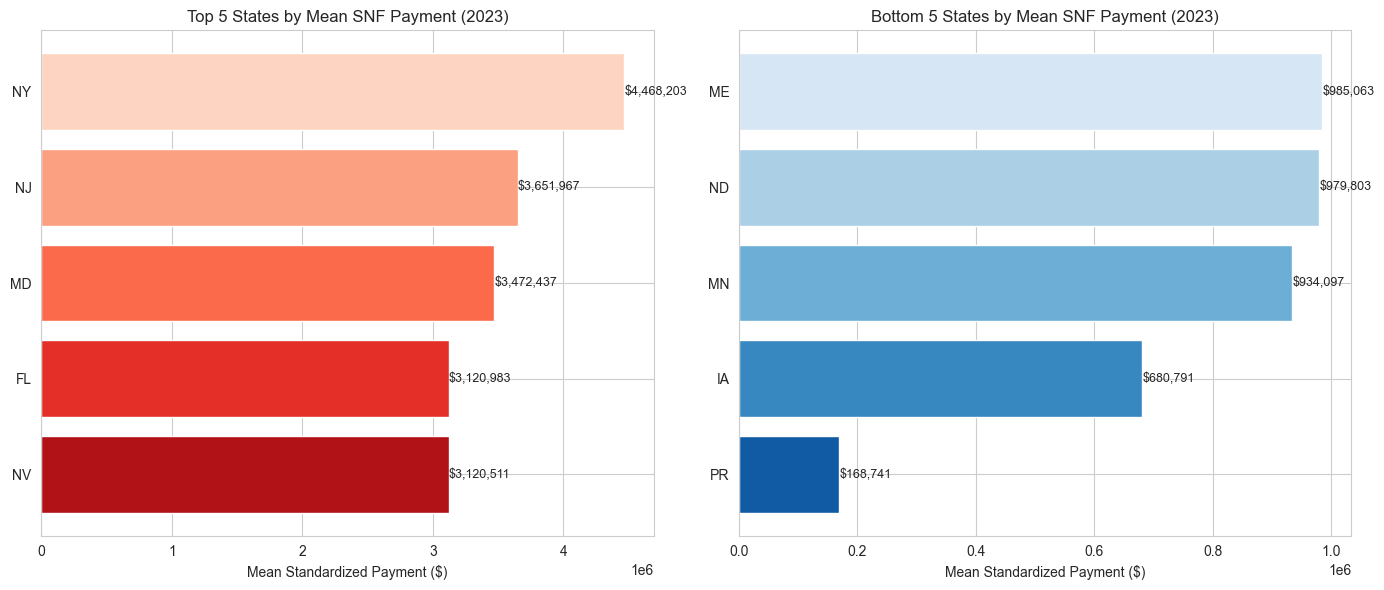

Saved: output/state_comparison.png


In [ ]:
# Bar chart: Top 5 and Bottom 5 states
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top5 = df_states[df_states['category'] == 'Top 5'].sort_values('mean_pymt', ascending=True)
bot5 = df_states[df_states['category'] == 'Bottom 5'].sort_values('mean_pymt', ascending=True)

# Top 5 (highest)
ax1.barh(top5['STATE'], top5['mean_pymt'], color=sns.color_palette('Reds_r', 5))
ax1.set_xlabel('Mean Standardized Payment ($)')
ax1.set_title('Top 5 States by Mean SNF Payment (2023)')
for i, (val, state) in enumerate(zip(top5['mean_pymt'], top5['STATE'])):
    ax1.text(val + 500, i, f'${val:,.0f}', va='center', fontsize=9)

# Bottom 5 (lowest)
ax2.barh(bot5['STATE'], bot5['mean_pymt'], color=sns.color_palette('Blues_r', 5))
ax2.set_xlabel('Mean Standardized Payment ($)')
ax2.set_title('Bottom 5 States by Mean SNF Payment (2023)')
for i, (val, state) in enumerate(zip(bot5['mean_pymt'], bot5['STATE'])):
    ax2.text(val + 200, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/state_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: output/state_comparison.png')

### Dual-Eligible Comparison

Compare mean `TOT_MDCR_STDZD_PYMT_AMT` for providers where `BENE_DUAL_PCT >= 50%` (high dual-eligible share) vs. `< 50%` (low dual-eligible share).

**Context:** Dual-eligible beneficiaries qualify for both Medicare and Medicaid, often indicating lower income. Facilities with a high share of dual-eligible patients may serve different populations and have different cost patterns.

In [ ]:
# Dual-eligible comparison
# BENE_DUAL_PCT contains '*' for CMS-suppressed values; TRY_CAST converts these to NULL
dual_sql = """
    SELECT
        CASE
            WHEN TRY_CAST(BENE_DUAL_PCT AS DOUBLE) >= 50 THEN 'High Dual (>= 50%)'
            ELSE 'Low Dual (< 50%)'
        END AS dual_category,
        COUNT(*) AS provider_count,
        ROUND(AVG(TOT_MDCR_STDZD_PYMT_AMT), 2) AS mean_pymt,
        ROUND(STDDEV(TOT_MDCR_STDZD_PYMT_AMT), 2) AS std_pymt
    FROM mcpac_snf_2023
    WHERE SMRY_CTGRY = 'PROVIDER'
      AND TOT_MDCR_STDZD_PYMT_AMT IS NOT NULL
      AND TRY_CAST(BENE_DUAL_PCT AS DOUBLE) IS NOT NULL
    GROUP BY dual_category
    ORDER BY dual_category
"""

df_dual = con.execute(dual_sql).fetchdf()
df_dual

,dual_category,provider_count,mean_pymt,std_pymt
0,High Dual (>= 50%),3951,1996815.81,1976113.10
1,Low Dual (< 50%),6503,2342311.15,2097567.52


In [10]:
# QC: Count of providers with suppressed BENE_DUAL_PCT
con.execute("""
    SELECT
        COUNT(*) AS total_providers,
        SUM(CASE WHEN TRY_CAST(BENE_DUAL_PCT AS DOUBLE) IS NULL THEN 1 ELSE 0 END) AS suppressed_dual_pct,
        ROUND(100.0 * SUM(CASE WHEN TRY_CAST(BENE_DUAL_PCT AS DOUBLE) IS NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_suppressed
    FROM mcpac_snf_2023
    WHERE SMRY_CTGRY = 'PROVIDER'
""").fetchdf()

,total_providers,suppressed_dual_pct,pct_suppressed
0,14161,3707.0,26.2


In [11]:
# Save Part 1 results to CSV
import csv

with open('output/summary_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    
    # Section 1: Summary Statistics
    writer.writerow(['=== Summary Statistics for TOT_MDCR_STDZD_PYMT_AMT (2023, PROVIDER rows) ==='])
    df_summary.to_csv(f, index=False)
    writer.writerow([])
    
    # Section 2: Top/Bottom States
    writer.writerow(['=== Top 5 and Bottom 5 States by Mean TOT_MDCR_STDZD_PYMT_AMT ==='])
    df_states.to_csv(f, index=False)
    writer.writerow([])
    
    # Section 3: Dual-Eligible Comparison
    writer.writerow(['=== Dual-Eligible Comparison (BENE_DUAL_PCT >= 50% vs < 50%) ==='])
    df_dual.to_csv(f, index=False)

print('Saved: output/summary_results.csv')

Saved: output/summary_results.csv


---
## Section 3: Part 2 — Longitudinal Trend (2019–2023)

This section builds a **balanced panel**: only providers (`PRVDR_ID`) that appear in all 5 years. This ensures year-over-year comparisons reflect actual payment trends, not confounding from facilities entering or exiting the dataset.

In [1]:
# Load all 5 years and UNION into one table
years = [2019, 2020, 2021, 2022, 2023]

for yr in years:
    csv_path = f'data/mcpac-snf_{yr}.csv'
    con.execute(f"""
        CREATE OR REPLACE TABLE mcpac_snf_{yr} AS
        SELECT * FROM read_csv_auto('{csv_path}', header=true, ignore_errors=true)
    """)
    count = con.execute(f"SELECT COUNT(*) FROM mcpac_snf_{yr}").fetchone()[0]
    print(f'{yr}: {count:,} rows loaded')

# Select only needed columns to avoid schema mismatches across years
union_parts = []
for yr in years:
    union_parts.append(f"""
        SELECT PRVDR_ID, STATE, SMRY_CTGRY,
               TOT_MDCR_STDZD_PYMT_AMT,
               {yr} AS year
        FROM mcpac_snf_{yr}
        WHERE SMRY_CTGRY = 'PROVIDER'
    """)

union_sql = " UNION ALL ".join(union_parts)
con.execute(f"CREATE OR REPLACE TABLE mcpac_snf_all AS {union_sql}")

# QC: Row counts by year
con.execute("""
    SELECT year, COUNT(*) AS provider_rows
    FROM mcpac_snf_all
    GROUP BY year
    ORDER BY year
""").fetchdf()

### Balanced Panel

A **balanced panel** restricts to providers observed in every time period, ensuring year-over-year comparisons reflect actual trends rather than composition changes from facilities entering or exiting the dataset.

In [ ]:
# Build balanced panel: providers present in all 5 years
panel_sql = """
    CREATE OR REPLACE TABLE mcpac_snf_panel AS
    SELECT *
    FROM mcpac_snf_all
    WHERE PRVDR_ID IN (
        SELECT PRVDR_ID
        FROM mcpac_snf_all
        GROUP BY PRVDR_ID
        HAVING COUNT(DISTINCT year) = 5
    )
"""

con.execute(panel_sql)
panel_size = con.execute("SELECT COUNT(DISTINCT PRVDR_ID) FROM mcpac_snf_panel").fetchone()[0]
print(f'Balanced panel size: {panel_size:,} providers')

Balanced panel size: 13,497 providers


In [ ]:
# QC: Verify equal provider count each year in the balanced panel
con.execute("""
    SELECT year, COUNT(DISTINCT PRVDR_ID) AS providers
    FROM mcpac_snf_panel
    GROUP BY year
    ORDER BY year
""").fetchdf()

,year,providers
0,2019,13497
1,2020,13497
2,2021,13497
3,2022,13497
4,2023,13497


In [ ]:
# Mean payment by year for balanced panel.
trend_sql = """
    SELECT
        year,
        COUNT(*) AS providers,
        ROUND(AVG(TOT_MDCR_STDZD_PYMT_AMT), 2) AS mean_pymt
    FROM mcpac_snf_panel
    WHERE TOT_MDCR_STDZD_PYMT_AMT IS NOT NULL
    GROUP BY year
    ORDER BY year
"""

df_trend = con.execute(trend_sql).fetchdf()
df_trend

,year,providers,mean_pymt
0,2019,13497,1850027.82
1,2020,13497,1894284.55
2,2021,13497,1861777.47
3,2022,13497,1901319.70
4,2023,13497,1882403.27


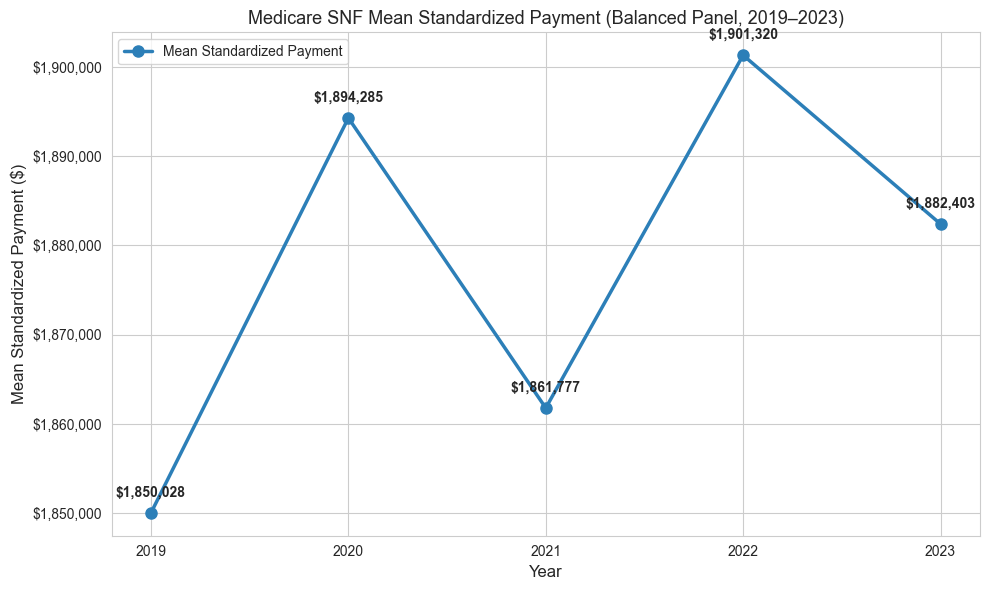

Saved: output/trend_chart.png


In [ ]:
# Line chart: Year vs. Average TOT_MDCR_STDZD_PYMT_AMT
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_trend['year'], df_trend['mean_pymt'], 'o-', color='#2c7fb8',
        linewidth=2.5, markersize=8, label='Mean Standardized Payment')

# Data labels
for _, row in df_trend.iterrows():
    ax.annotate(f"${row['mean_pymt']:,.0f}",
                xy=(row['year'], row['mean_pymt']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Standardized Payment ($)', fontsize=12)
ax.set_title('Medicare SNF Mean Standardized Payment (Balanced Panel, 2019–2023)', fontsize=13)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('output/trend_chart.png', bbox_inches='tight')
plt.show()
print('Saved: output/trend_chart.png')

In [ ]:
# Save trend data
df_trend.to_csv('output/trend_data.csv', index=False)
print('Saved: output/trend_data.csv')

Saved: output/trend_data.csv


---
## Section 4: Write-Up

### Data Sources
- CMS Medicare Post-Acute Care & Hospice — SNF Utilization data (2019–2023)
- Accessed February 2026 from data.cms.gov
- One CSV file per year; provider-level records identified by `PRVDR_ID`

### Methodology
- **Filtering:** Retained only `SMRY_CTGRY = 'PROVIDER'` rows (excludes STATE and NATIONAL summary rows)
- **Means:** All means are unweighted (each provider counts equally)
- **Missing/suppressed values:** `BENE_DUAL_PCT` contains `'*'` for CMS-suppressed small cells. These were converted to NULL using `TRY_CAST()` and excluded from the dual-eligible comparison. `TOT_MDCR_STDZD_PYMT_AMT` had no missing values in 2023.
- **Balanced panel:** For Part 2, restricted to providers appearing in all 5 years (2019–2023) to avoid composition bias
- **Rounding:** All results rounded to 2 decimal places per instructions

### Key Findings

**Part 1 (2023):**
- **14,161** providers with a mean standardized payment of **$1,846,517.51** (median $1,257,114 — distribution is right-skewed)
- **Top 5 states:** NY ($4,468,203), NJ ($3,651,967), MD ($3,472,437), FL ($3,120,983), NV ($3,120,511)
- **Bottom 5 states:** ME ($985,063), ND ($979,803), MN ($934,097), IA ($680,791), PR ($168,741)
- Puerto Rico's mean ($168K) is dramatically lower than any state, likely reflecting different reimbursement structures
- **Dual-eligible comparison:** Providers with ≥ 50% dual-eligible beneficiaries had **lower** mean payments ($1,996,816) compared to those with < 50% ($2,342,311). This suggests facilities serving more low-income populations tend to have lower total standardized payments.
- Note: 3,707 providers (~26%) had suppressed `BENE_DUAL_PCT` and were excluded from this comparison

**Part 2 (2019–2023 Balanced Panel):**
- **13,497** providers present in all 5 years (~91% of 2019 providers)
- Payment trend shows a **modest overall increase** from $1,850,028 (2019) to $1,882,403 (2023), a ~1.7% rise over 5 years
- Notable pattern: spike in 2020 ($1,894,285), dip in 2021 ($1,861,777), recovery in 2022 ($1,901,320), slight decline in 2023 ($1,882,403)
- The 2020 spike and 2021 dip likely reflect COVID-19 impacts on SNF utilization and acuity

### QC Checks Performed
1. Row counts by `SMRY_CTGRY`: confirmed 14,161 PROVIDER + 52 STATE + 1 NATIONAL rows (2023)
2. Null counts on key columns: zero nulls for `PRVDR_ID`, `STATE`, `TOT_MDCR_STDZD_PYMT_AMT` in PROVIDER rows
3. Duplicate `PRVDR_ID` check: no duplicates among PROVIDER rows
4. Suppressed `BENE_DUAL_PCT` values identified and quantified (~26% of providers)
5. Balanced panel verified: equal provider count (13,497) in each of the 5 years
6. Year-over-year provider counts checked during data loading

### Limitations
- **Unweighted means** treat all providers equally regardless of size (patient volume). Weighted means by beneficiary count would better reflect the average patient experience.
- **Suppressed `BENE_DUAL_PCT`** values (~26% of providers) were excluded rather than imputed, which may introduce bias if suppression correlates with facility size or payment levels.
- **Standardized payments** adjust for geographic wage differences but may not fully capture cost-of-living variation.
- **Balanced panel** excludes ~1,300 providers that opened or closed during 2019–2023, potentially missing trends in new vs. closing facilities.
- **No risk adjustment** beyond what CMS standardization provides — differences across states or dual-eligible groups may reflect case mix, not efficiency.
- **COVID-19 effects** on 2020–2021 data are not explicitly controlled for; the observed spike/dip pattern warrants further investigation.

In [ ]:
# Section 5: Cleanup
con.close()
print('DuckDB connection closed. Analysis complete.')

DuckDB connection closed. Analysis complete.
